# Titanic EDA Project
Clean Submission Notebook

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Q1: Data Types & Missing Values

In [2]:
print(df.dtypes)
print("\nMissing Values Before:\n", df.isnull().sum())

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

Missing Values Before:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


## Q2: Duplicate Check

In [3]:
print("Exact duplicates:", df.duplicated().sum())

duplicates = df[df.duplicated(subset=['sex','age','pclass','fare'])]
duplicates.head()

Exact duplicates: 107


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
42,0,3,male,NaN,0,0,7.8958,C,Third,man,True,NaN,Cherbourg,no,True
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Q3: Fill Missing Age

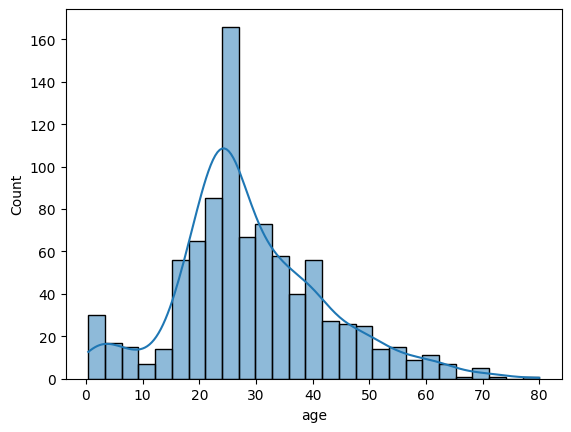

In [4]:
df['age'] = df.groupby(['pclass','sex'])['age'].transform(lambda x: x.fillna(x.median()))

sns.histplot(df['age'], kde=True)
plt.show()

## Q4: Fill Missing Embarked

In [5]:
mode_port = df[df['pclass']==1]['embarked'].mode()[0]
df['embarked'].fillna(mode_port, inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_13424\2544113206.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['embarked'].fillna(mode_port, inplace=True)


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: str

## Q5: Deck Analysis

In [6]:
df['deck_known'] = df['deck'].notnull()
print(df.groupby('deck_known')['survived'].mean())

deck_known
False    0.299419
True     0.669951
Name: survived, dtype: float64


## Q6: Family Features

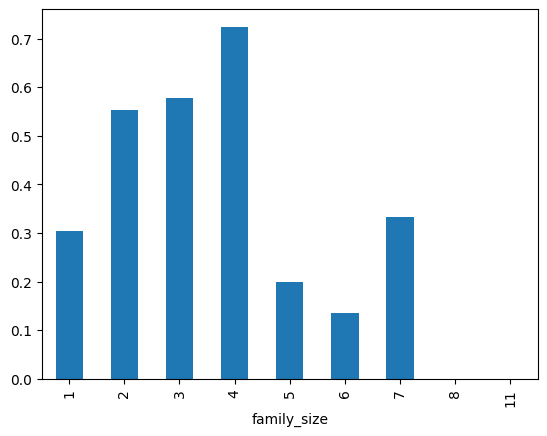

In [7]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = df['family_size'] == 1

df.groupby('family_size')['survived'].mean().plot(kind='bar')
plt.show()

## Q7: Child Analysis

In [8]:
df['is_child'] = df['age'] < 18
mismatch = df[(df['is_child']==True) & (df['who']!='child')]
mismatch.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,deck_known,family_size,is_alone,is_child
68,1,3,female,17.0,4,2,7.9250,S,Third,woman,False,NaN,Southampton,yes,False,False,7,False,True
71,0,3,female,16.0,5,2,46.9000,S,Third,woman,False,NaN,Southampton,no,False,False,8,False,True
84,1,2,female,17.0,0,0,10.5000,S,Second,woman,False,NaN,Southampton,yes,True,False,1,True,True
86,0,3,male,16.0,1,3,34.3750,S,Third,man,True,NaN,Southampton,no,False,False,5,False,True
114,0,3,female,17.0,0,0,14.4583,C,Third,woman,False,NaN,Cherbourg,no,True,False,1,True,True


## Q8: Fare Per Person

In [9]:
df['fare_per_person'] = df['fare'] / df['family_size']

df['fare_bin'] = pd.cut(df['fare'], bins=5)
df['fpp_bin'] = pd.cut(df['fare_per_person'], bins=5)

df.groupby('fare_bin')['survived'].mean()
df.groupby('fpp_bin')['survived'].mean()

fpp_bin
(-0.512, 102.466]     0.372842
(102.466, 204.932]    0.857143
(204.932, 307.398]    0.666667
(409.863, 512.329]    1.000000
Name: survived, dtype: float64

## Q9: Survival by Sex & Class

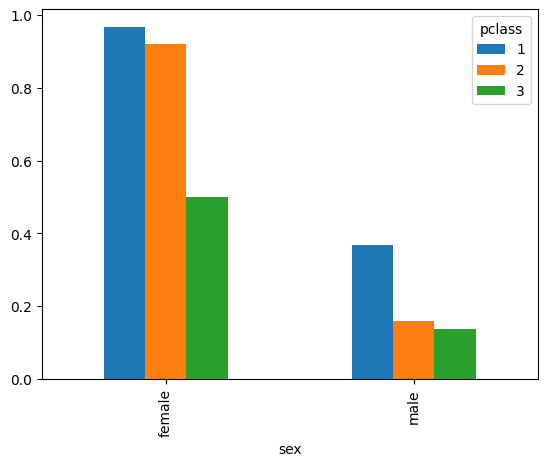

In [10]:
df.groupby(['sex','pclass'])['survived'].mean().unstack().plot(kind='bar')
plt.show()

## Q10: Embark Town Analysis

In [11]:
print(df.groupby('embark_town')['survived'].mean())
print(df.groupby(['embark_town','pclass'])['survived'].mean())

embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.336957
Name: survived, dtype: float64
embark_town  pclass
Cherbourg    1         0.694118
             2         0.529412
             3         0.378788
Queenstown   1         0.500000
             2         0.666667
             3         0.375000
Southampton  1         0.582677
             2         0.463415
             3         0.189802
Name: survived, dtype: float64


## Q11: Alone vs Family

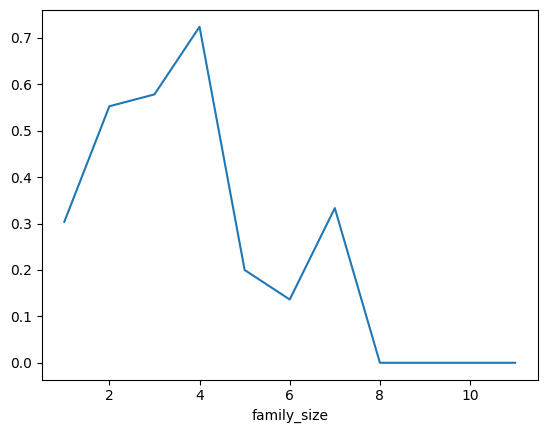

In [12]:
df.groupby('alone')['survived'].mean()
df.groupby('family_size')['survived'].mean().plot()
plt.show()

## Q12: Age Analysis

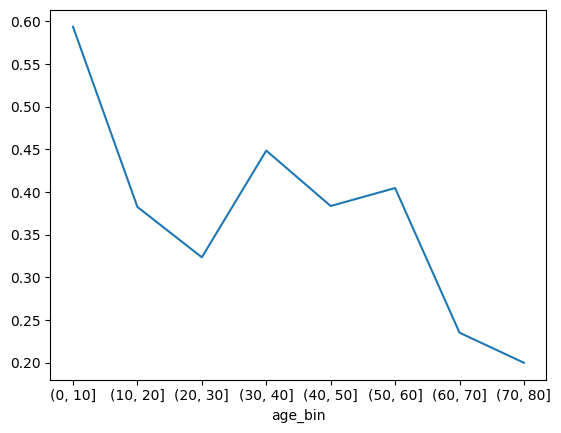

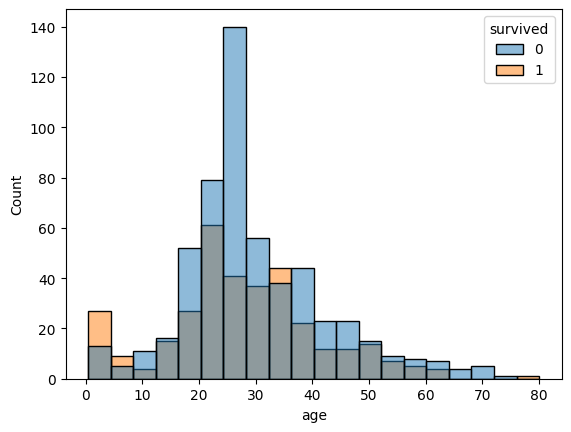

In [13]:
bins = [0,10,20,30,40,50,60,70,80]
df['age_bin'] = pd.cut(df['age'], bins)

df.groupby('age_bin')['survived'].mean().plot()
plt.show()

sns.histplot(data=df, x='age', hue='survived', bins=20)
plt.show()

## Q13: Correlation

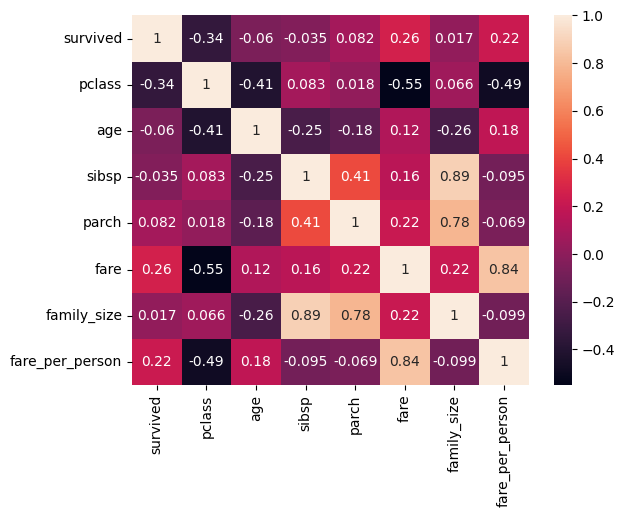

In [14]:
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True)
plt.show()

## Q14: Survival Score

In [15]:
df['survival_score'] = (
    (df['sex']=='female').astype(int) +
    (df['pclass']==1).astype(int) +
    (df['fare'] > df['fare'].median()).astype(int)
)

pivot = df.pivot_table(values='survived', index='sex', columns='pclass')
pivot

pclass,1,2,3
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


## Executive Summary (WRITE THIS IN ASSIGNMENT)
Survival was mainly influenced by gender, class, and fare

Females had much higher survival due to rescue priority

First-class passengers had better access to lifeboats

Wealth (fare) increased survival chances

Small families survived more than large or single passengers

## Final Conclusion:
Survival was strongly affected by social class, gender norms, and economic status, not random chance.